# Baseline Model: IoT-23 Binary Classification

In [32]:
import numpy as np
import pandas as pd
import random
from pathlib import Path

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

DATA_PATH = Path("../data/iot23_processed/iot23_binary_flows.csv")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok = True)

### 1) Dataset Loading and Cleaning
##### Loads the IoT-23 processed flow dataset. Missing values represented as '-' are converted to NaN and removed to ensure numerical compatibility with machine learning models


In [33]:
# Load and clean the data
df = pd.read_csv(DATA_PATH)

# Replace Zeek placeholder "-" with NA
df.replace("-", pd.NA, inplace = True)

# Convert numeric columns
numeric_cols = [
    "duration",
    "orig_bytes",
    "resp_bytes",
    "orig_pkts",
    "resp_pkts",
    "orig_ip_bytes",
    "resp_ip_bytes"
]

# Convert columns to numeric, coercing errors to NaN
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors = "coerce")

# Drop rows with missing numeric values or missing label
df.dropna(subset = numeric_cols + ["binary_label"], inplace = True)

# Reset index after dropping rows
df.reset_index(drop = True, inplace = True)

print("After cleaning:", df.shape)
print(df["binary_label"].value_counts())

After cleaning: (2291, 13)
binary_label
BENIGN       1527
MALICIOUS     764
Name: count, dtype: int64


### 2) Feature Selection 
##### Flow-level numerical features selected and encode the binary label as 0 for benign and 1 for malicious

In [3]:
# Prepare features and labels
feature_cols = [
    "duration",
    "orig_bytes",
    "resp_bytes",
    "orig_pkts",
    "resp_pkts",
]

# Drop rows with missing values in features or label
df = df.dropna(subset = feature_cols + ["binary_label"]).copy()
X = df[feature_cols]
# Convert binary label to 0 for benign and 1 for malicious
y = (df["binary_label"] == "MALICIOUS").astype(int)

print("X:", X.shape, "y:", y.shape)
print(y.value_counts())

X: (2291, 5) y: (2291,)
binary_label
0    1527
1     764
Name: count, dtype: int64


### 3) Encode Categorical Features
##### Network protocol, service type and connection state are categorical features so we convert them into numeric format

In [4]:
# Encode categorical variables using one-hot encoding
categorical_cols = ["proto", "service", "conn_state"]
df_encoded = pd.get_dummies(df, columns = categorical_cols, drop_first = True)
print("After encoding:", df_encoded.shape)

After encoding: (2291, 24)


### 4) Define Feature and Target Variables
##### Separate input features (X) from the binary target label (y)

In [5]:
# Prepare features and target variable
feature_cols = [
    col for col in df_encoded.columns
    if col not in ["binary_label", "ts", "capture_name"]
]

# Create feature matrix X and target vector y
X = df_encoded[feature_cols]
y = (df_encoded["binary_label"] == "MALICIOUS").astype(int)

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature matrix shape: (2291, 21)
Target distribution:
 binary_label
0    1527
1     764
Name: count, dtype: int64


### 5) Train-test Split
##### Dataset is split into training and testing subsets using a 70/30 split to preserve class distribution

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (1603, 21)
Test size: (688, 21)


### 6) Random Forest Model Training
##### A Random Forest classifier is trained as the baseline model due to its robustness and ability to handle non-linear decision boundaries

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Random Forest
rf = RandomForestClassifier(n_estimators = 200, random_state = 42, n_jobs = -1)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       459
           1       1.00      0.98      0.99       229

    accuracy                           0.99       688
   macro avg       1.00      0.99      0.99       688
weighted avg       0.99      0.99      0.99       688

ROC-AUC: 0.9999143762308417


### 7) Logistic Regression Baseline
##### Logistic Regression classifier is trained and evaluated under the same conditions as the Random Forest model

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Logistic Regression with scaling (for XGBoost)
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter = 5000, random_state = 42))
])

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       459
           1       1.00      0.98      0.99       229

    accuracy                           0.99       688
   macro avg       0.99      0.99      0.99       688
weighted avg       0.99      0.99      0.99       688

ROC-AUC: 0.9895729276669426


### 8) Decision Tree Classifier
##### A single Decision Tree model is trained to compare against ensemble methods

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import time

# Measure training time
start = time.time()
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(X_train, y_train)
dt_train_time = time.time() - start

# Predict probabilities and classes
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree Results:")
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))
print("Training time: {:.4f} seconds".format(dt_train_time))

Decision Tree Results:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       459
           1       1.00      0.98      0.99       229

    accuracy                           0.99       688
   macro avg       0.99      0.99      0.99       688
weighted avg       0.99      0.99      0.99       688

ROC-AUC: 0.9879936448135781
Training time: 0.0050 seconds


### 9) XGBoost Classifier
##### XGBoost is trained under identical conditions to compare boosting performance against Random Forest and single-tree models

In [ ]:
from xgboost import XGBClassifier
import time

# Start timing
start = time.time()

# Train XGBoost model with early stopping
xgb = XGBClassifier(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    eval_metric = "logloss",
    n_jobs = -1
)
# Use early stopping on a validation set
xgb.fit(X_train, y_train)
xgb_train_time = time.time() - start

# Predict probabilities and classes
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("Training time: {:.4f} seconds".format(xgb_train_time))

XGBoost Results:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       459
           1       1.00      0.99      0.99       229

    accuracy                           1.00       688
   macro avg       1.00      0.99      1.00       688
weighted avg       1.00      1.00      1.00       688

ROC-AUC: 0.9984492584030216
Training time: 0.0706 seconds


### LightGBM Model
##### LightGBM is an efficient gradient boosting framework designed for high performance and low memory usage and is particularly suited for large-scale and resource-constrained environments

In [11]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Initialise LightGBM classifier
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

# Train model
lgbm.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Evaluation
print("LightGBM Results:")
print(classification_report(y_test, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgbm))


[LightGBM] [Info] Number of positive: 535, number of negative: 1068
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 583
[LightGBM] [Info] Number of data points in the train set: 1603, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333749 -> initscore=-0.691276
[LightGBM] [Info] Start training from score -0.691276
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

### Comparison Table

In [12]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

results = {
    "Model": [
        "Decision Tree",
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgbm)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_lgbm)
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,F1 Score,ROC-AUC
0,Decision Tree,0.991279,0.986784,0.987994
1,Logistic Regression,0.992733,0.988962,0.989573
2,Random Forest,0.994186,0.991189,0.999914
3,XGBoost,0.995640,0.993407,0.998449
4,LightGBM,0.998547,0.997812,0.999429


### Model sizes

In [ ]:
# Used to save the models and report their sizes
import joblib
import os
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents = True, exist_ok = True)

rf_path = models_dir / "rf_model.joblib"
lr_path = models_dir / "log_reg_model.joblib"
dt_path = models_dir / "decision_tree_model.joblib"
xgb_path = models_dir / "xgb_model.joblib"
lgbm_path = models_dir / "lgbm_model.joblib"

joblib.dump(lgbm, lgbm_path)
joblib.dump(dt, dt_path)
joblib.dump(rf, rf_path)
joblib.dump(log_reg, lr_path)
joblib.dump(xgb, xgb_path)

rf_size = os.path.getsize(rf_path) / 1024
lr_size = os.path.getsize(lr_path) / 1024
dt_size = os.path.getsize(dt_path) / 1024
xgb_size = os.path.getsize(xgb_path) / 1024
lgbm_size = os.path.getsize(lgbm_path) / 1024

print(f"Random Forest size: {rf_size:.2f} KB")
print(f"Logistic Regression size: {lr_size:.2f} KB")
print(f"Decision Tree size: {dt_size:.2f} KB")
print(f"XGBoost size: {xgb_size:.2f} KB")
print(f"LightGBM size: {lgbm_size:.2f} KB")

Random Forest size: 598.04 KB
Logistic Regression size: 2.49 KB
Decision Tree size: 4.06 KB
XGBoost size: 181.76 KB
LightGBM size: 392.10 KB


## Capture-Based Train-Test Split
##### To better evaluate generalisation, we now split the dataset by capture

In [15]:
# Define test captures (completely unseen scenarios)
test_captures = ["honeypot_5", "malware_17"]

train_df = df_encoded[~df_encoded["capture_name"].isin(test_captures)]
test_df = df_encoded[df_encoded["capture_name"].isin(test_captures)]

print("Train captures:")
print(train_df["capture_name"].value_counts())

print("\nTest captures:")
print(test_df["capture_name"].value_counts())

# Define features
feature_cols = [
    col for col in df_encoded.columns
    if col not in ["binary_label", "ts", "capture_name"]
]

X_train = train_df[feature_cols]
y_train = (train_df["binary_label"] == "MALICIOUS").astype(int)

X_test = test_df[feature_cols]
y_test = (test_df["binary_label"] == "MALICIOUS").astype(int)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

Train captures:
capture_name
honeypot_4    451
malware_1     119
malware_3      46
malware_7       3
malware_20      2
Name: count, dtype: int64

Test captures:
capture_name
honeypot_5    1076
malware_17     594
Name: count, dtype: int64

Train size: (621, 21)
Test size: (1670, 21)


### Random Forest (Capture Split)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

rf_capture = RandomForestClassifier(n_estimators = 200, random_state = 42, n_jobs = -1)

rf_capture.fit(X_train, y_train)

y_pred_capture = rf_capture.predict(X_test)
y_proba_capture = rf_capture.predict_proba(X_test)[:, 1]

print("\nRandom Forest (Capture Split) Results:")
print(classification_report(y_test, y_pred_capture))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_capture))


Random Forest (Capture Split) Results:
              precision    recall  f1-score   support

           0       1.00      0.81      0.89      1076
           1       0.74      1.00      0.85       594

    accuracy                           0.88      1670
   macro avg       0.87      0.90      0.87      1670
weighted avg       0.91      0.88      0.88      1670

ROC-AUC: 0.9995196700587035


### Logistic Regression (Capture Split)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression with scaling (for XGBoost)
log_reg_capture = LogisticRegression(max_iter = 10000)
log_reg_capture.fit(X_train, y_train)

y_pred_lr_capture = log_reg_capture.predict(X_test)
y_proba_lr_capture = log_reg_capture.predict_proba(X_test)[:, 1]

print("\nLogistic Regression (Capture Split) Results:")
print(classification_report(y_test, y_pred_lr_capture))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr_capture))


Logistic Regression (Capture Split) Results:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      1076
           1       0.84      1.00      0.91       594

    accuracy                           0.93      1670
   macro avg       0.92      0.95      0.93      1670
weighted avg       0.94      0.93      0.93      1670

ROC-AUC: 0.9859656039953438


### Decision Tree (Capture Split)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_capture = DecisionTreeClassifier(random_state = 42)

dt_capture.fit(X_train, y_train)

y_pred_dt_capture = dt_capture.predict(X_test)
y_proba_dt_capture = dt_capture.predict_proba(X_test)[:, 1]

print("\nDecision Tree (Capture Split) Results:")
print(classification_report(y_test, y_pred_dt_capture))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt_capture))


Decision Tree (Capture Split) Results:
              precision    recall  f1-score   support

           0       1.00      0.81      0.89      1076
           1       0.74      1.00      0.85       594

    accuracy                           0.88      1670
   macro avg       0.87      0.90      0.87      1670
weighted avg       0.91      0.88      0.88      1670

ROC-AUC: 0.903898026109922


### XGBoost (Capture Split)

In [ ]:
from xgboost import XGBClassifier

xgb_capture = XGBClassifier(eval_metric = "logloss",random_state = 42)

xgb_capture.fit(X_train, y_train)

y_pred_xgb_capture = xgb_capture.predict(X_test)
y_proba_xgb_capture = xgb_capture.predict_proba(X_test)[:, 1]

print("\nXGBoost (Capture Split) Results:")
print(classification_report(y_test, y_pred_xgb_capture))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_capture))



XGBoost (Capture Split) Results:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      1076
           1       0.83      1.00      0.91       594

    accuracy                           0.93      1670
   macro avg       0.92      0.94      0.92      1670
weighted avg       0.94      0.93      0.93      1670

ROC-AUC: 0.9906718986644637


### LightGBM (Capture Split)

In [ ]:
from lightgbm import LGBMClassifier

lgbm_capture = LGBMClassifier(random_state = 42)

lgbm_capture.fit(X_train, y_train)

y_pred_lgbm_capture = lgbm_capture.predict(X_test)
y_proba_lgbm_capture = lgbm_capture.predict_proba(X_test)[:, 1]

print("\nLightGBM (Capture Split) Results:")
print(classification_report(y_test, y_pred_lgbm_capture))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgbm_capture))

[LightGBM] [Info] Number of positive: 170, number of negative: 451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000231 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 337
[LightGBM] [Info] Number of data points in the train set: 621, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.273752 -> initscore=-0.975669
[LightGBM] [Info] Start training from score -0.975669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

### Comparsion Table (Capture Split)

In [21]:
from sklearn.metrics import accuracy_score, f1_score

capture_results = {
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "Decision Tree",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_capture),
        accuracy_score(y_test, y_pred_lr_capture),
        accuracy_score(y_test, y_pred_dt_capture),
        accuracy_score(y_test, y_pred_xgb_capture),
        accuracy_score(y_test, y_pred_lgbm_capture)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_capture),
        f1_score(y_test, y_pred_lr_capture),
        f1_score(y_test, y_pred_dt_capture),
        f1_score(y_test, y_pred_xgb_capture),
        f1_score(y_test, y_pred_lgbm_capture)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_capture),
        roc_auc_score(y_test, y_proba_lr_capture),
        roc_auc_score(y_test, y_proba_dt_capture),
        roc_auc_score(y_test, y_proba_xgb_capture),
        roc_auc_score(y_test, y_proba_lgbm_capture)
    ]
}

pd.DataFrame(capture_results)


,Model,Accuracy,F1 Score,ROC-AUC
0,Random Forest,0.877246,0.852836,0.999520
1,Logistic Regression,0.929940,0.910345,0.985966
2,Decision Tree,0.876647,0.852011,0.903898
3,XGBoost,0.927545,0.907563,0.990672
4,LightGBM,0.822156,0.800000,0.977694


### Random vs Capture Comparison Table

In [22]:
random_results = comparison_df.copy()
random_results["Split"] = "Random"

capture_results_df = pd.DataFrame(capture_results)
capture_results_df["Split"] = "Capture"

combined_results = pd.concat([random_results, capture_results_df])
combined_results

,Model,Accuracy,F1 Score,ROC-AUC,Split
0,Decision Tree,0.991279,0.986784,0.987994,Random
1,Logistic Regression,0.992733,0.988962,0.989573,Random
2,Random Forest,0.994186,0.991189,0.999914,Random
3,XGBoost,0.995640,0.993407,0.998449,Random
4,LightGBM,0.998547,0.997812,0.999429,Random
0,Random Forest,0.877246,0.852836,0.999520,Capture
1,Logistic Regression,0.929940,0.910345,0.985966,Capture
2,Decision Tree,0.876647,0.852011,0.903898,Capture
3,XGBoost,0.927545,0.907563,0.990672,Capture
4,LightGBM,0.822156,0.800000,0.977694,Capture


## Group-Based Cross-Validation
##### Using GroupKFold to evaluate generalisation more robustly, using capture_name as the grouping variable

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Define features
feature_cols = [
    col for col in df_encoded.columns
    if col not in ["binary_label", "ts", "capture_name"]
]

X_full = df_encoded[feature_cols]
y_full = (df_encoded["binary_label"] == "MALICIOUS").astype(int)
groups = df_encoded["capture_name"]

# Initialize GroupKFold
gkf = GroupKFold(n_splits=3)

# Storage for results
cv_results = {
    "Model": [],
    "Fold": [],
    "Accuracy": [],
    "F1 Score": [],
    "ROC-AUC": []
}

models = {
    "Random Forest": RandomForestClassifier(n_estimators = 200, random_state = 42, n_jobs = -1),
    "Logistic Regression": LogisticRegression(max_iter = 10000),
    "Decision Tree": DecisionTreeClassifier(random_state = 42),
    "XGBoost": XGBClassifier(eval_metric = "logloss", random_state = 42),
    "LightGBM": LGBMClassifier(random_state = 42)
}

# Perform GroupKFold cross-validation
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_full, y_full, groups)):
    
    X_train_cv, X_test_cv = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_train_cv, y_test_cv = y_full.iloc[train_idx], y_full.iloc[test_idx]
    
    for name, model in models.items():
        
        model.fit(X_train_cv, y_train_cv)
        
        y_pred_cv = model.predict(X_test_cv)
        y_proba_cv = model.predict_proba(X_test_cv)[:, 1]
        
        cv_results["Model"].append(name)
        cv_results["Fold"].append(fold + 1)
        cv_results["Accuracy"].append(accuracy_score(y_test_cv, y_pred_cv))
        cv_results["F1 Score"].append(f1_score(y_test_cv, y_pred_cv))
        cv_results["ROC-AUC"].append(roc_auc_score(y_test_cv, y_proba_cv))

cv_df = pd.DataFrame(cv_results)
cv_df

c:\Users\Aminb\Documents\Leeds\Year 3\Final Year Project\iot-edge-ids\venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Aminb\Documents\Leeds\Year 3\Final Year Project\iot-edge-ids\venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Aminb\Documents\Leeds\Year 3\Final Year Project\iot-edge-ids\venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Aminb\Documents\Leeds\Year 3\Final Year Project\iot-edge-ids\venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Ami

[LightGBM] [Info] Number of positive: 764, number of negative: 451
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 387
[LightGBM] [Info] Number of data points in the train set: 1215, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628807 -> initscore=0.527100
[LightGBM] [Info] Start training from score 0.527100
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Users\Aminb\Documents\Leeds\Year 3\Final Year Project\iot-edge-ids\venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Aminb\Documents\Leeds\Year 3\Final Year Project\iot-edge-ids\venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Aminb\Documents\Leeds\Year 3\Final Year Project\iot-edge-ids\venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Aminb\Documents\Leeds\Year 3\Final Year Project\iot-edge-ids\venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Ami

[LightGBM] [Info] Number of positive: 165, number of negative: 1527
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 654
[LightGBM] [Info] Number of data points in the train set: 1692, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.097518 -> initscore=-2.225115
[LightGBM] [Info] Start training from score -2.225115
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

,Model,Fold,Accuracy,F1 Score,ROC-AUC
0,Random Forest,1,0.791822,0.000000,NaN
1,Logistic Regression,1,0.864312,0.000000,NaN
2,Decision Tree,1,0.798327,0.000000,NaN
3,XGBoost,1,0.763941,0.000000,NaN
4,LightGBM,1,0.730483,0.000000,NaN
5,Random Forest,2,0.998331,0.999165,NaN
6,Logistic Regression,2,0.989983,0.994966,NaN
7,Decision Tree,2,0.005008,0.009967,NaN
8,XGBoost,2,0.008347,0.016556,NaN
9,LightGBM,2,0.994992,0.997490,NaN


In [24]:
cv_summary = cv_df.groupby("Model").mean().reset_index()
cv_summary

,Model,Fold,Accuracy,F1 Score,ROC-AUC
0,Decision Tree,2.0,0.511826,0.029393,0.513452
1,LightGBM,2.0,0.879812,0.617428,0.870974
2,Logistic Regression,2.0,0.942774,0.648004,0.947390
3,Random Forest,2.0,0.922475,0.651620,0.984116
4,XGBoost,2.0,0.584269,0.326506,0.961500


In [25]:
cv_df.groupby("Model")[["Accuracy","F1 Score","ROC-AUC"]].std()

,Accuracy,F1 Score,ROC-AUC
Model,,,
Decision Tree,0.440163,0.042571,NaN
LightGBM,0.135520,0.539447,NaN
Logistic Regression,0.068417,0.561657,NaN
Random Forest,0.113638,0.564738,NaN
XGBoost,0.510383,0.551250,NaN


#### IoT-23 captures are mainly single-class so GroupKFold produces degenerate folds. Capture Split evalualtion is more appropriate

## Feature Importance Detection
##### Analyse which flow-level features most strongly influence model predictions. This helps interpret model behaviour and understand which network characteristics drive malicious detection

### Random Forest Feature Importance

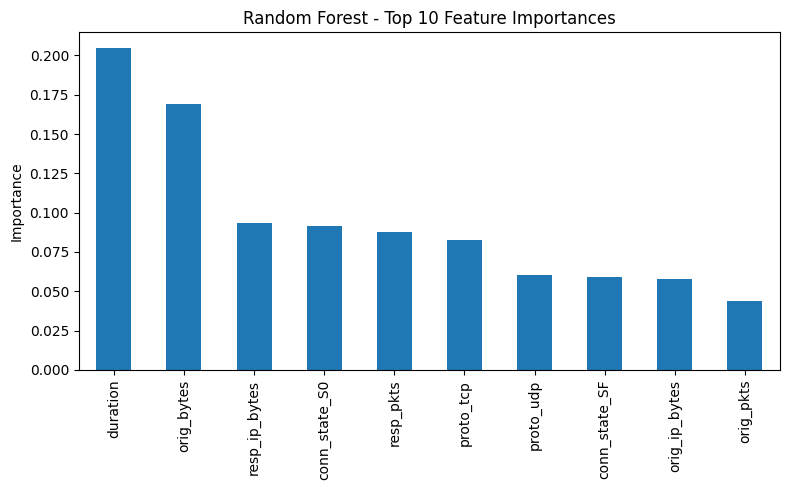

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importance
rf_importances = pd.Series(rf.feature_importances_, index = X.columns).sort_values(ascending = False)

# Plot top 10
plt.figure(figsize = (8,5))
rf_importances.head(10).plot(kind = "bar")
plt.title("Random Forest - Top 10 Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


### XGBoost Feature Importance

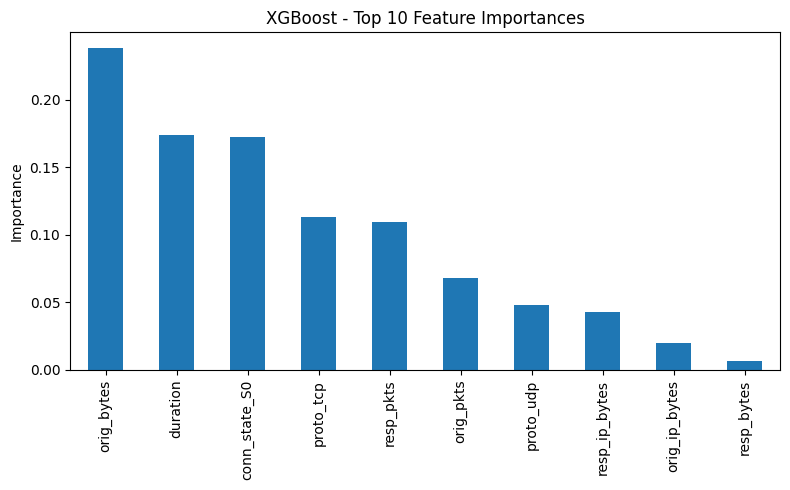

In [30]:
xgb_importances = pd.Series(xgb.feature_importances_, index = X.columns).sort_values(ascending = False)

plt.figure(figsize = (8,5))
xgb_importances.head(10).plot(kind = "bar")
plt.title("XGBoost - Top 10 Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


### LightGBM Feature Importance

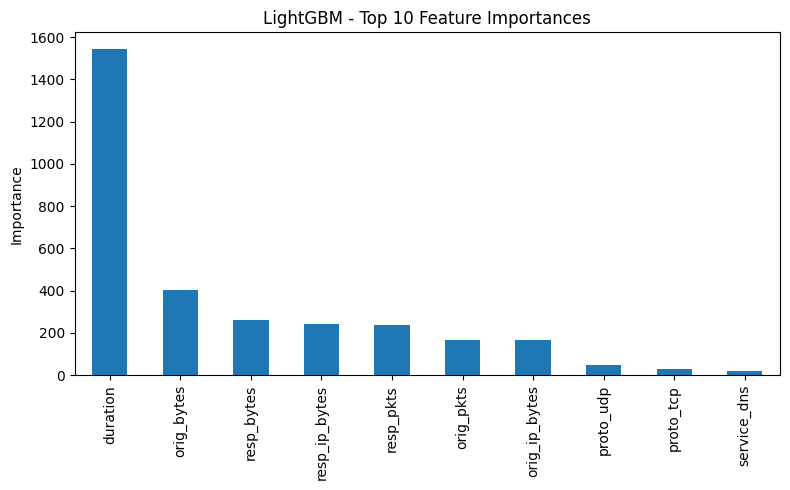

In [31]:
lgb_importances = pd.Series(lgbm.feature_importances_, index = X.columns).sort_values(ascending = False)

plt.figure(figsize = (8,5))
lgb_importances.head(10).plot(kind = "bar")
plt.title("LightGBM - Top 10 Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


### Integration of Real-World Benign Traffic and Realistic Evaluation

##### To improve the realism of benign traffic representation, additional network traffic was captured from a Raspberry Pi device operating under normal conditions.

##### This data is transformed to match the IoT-23 feature format and integrated with the existing dataset.

##### To simulate realistic deployment conditions, models are trained on a balanced dataset and evaluated on imbalanced test sets representing:

##### 95% benign / 5% malicious
##### 99% benign / 1% malicious

In [ ]:
pi_df = pd.read_csv("../data/normal_traffic_01_flow_features.csv")
pi_clean = pi_df.copy()

# Rename
pi_clean = pi_clean.rename(columns={
    "duration_s": "duration",
    "total_bytes": "orig_bytes",
    "packet_count": "orig_pkts",
    "protocol": "proto"
})

# Protocol mapping
proto_map = {6: "tcp", 17: "udp"}
pi_clean["proto"] = pi_clean["proto"].map(proto_map).fillna("other")

# Create missing fields
pi_clean["resp_bytes"] = 0
pi_clean["resp_pkts"] = 0
pi_clean["orig_ip_bytes"] = pi_clean["orig_bytes"]
pi_clean["resp_ip_bytes"] = 0

# Add placeholders
pi_clean["conn_state"] = "SF"
pi_clean["service"] = "unknown"

# Metadata
pi_clean["binary_label"] = 0
pi_clean["capture_name"] = "pi_benign"
pi_clean["ts"] = pi_clean["start_time"]

# Select columns
target_cols = [
    "ts","proto","service","duration","orig_bytes","resp_bytes", "conn_state","orig_pkts","orig_ip_bytes","resp_pkts",
    "resp_ip_bytes","binary_label","capture_name"
]

pi_clean = pi_clean[target_cols]

# Clean
for col in ["duration","orig_bytes","resp_bytes","orig_pkts", "resp_pkts","orig_ip_bytes","resp_ip_bytes"]:
    pi_clean[col] = pd.to_numeric(pi_clean[col], errors="coerce")

pi_clean.dropna(inplace = True)
pi_clean.reset_index(drop = True, inplace = True)

print(pi_clean.shape)

(2016, 13)


##### Raspberry Pi traffic is transformed to match IoT-23 feature format and merged with the dataset

In [ ]:
df_unbal = pd.read_csv("../data/iot23_processed/iot23_full_unbalanced.csv")

# Fix data types
df_unbal = df_unbal.replace("-", np.nan)

for col in numeric_cols:
    if col in df_unbal.columns:
        df_unbal[col] = pd.to_numeric(df_unbal[col], errors = "coerce")

df_unbal.dropna(inplace = True)

# Convert label
df_unbal["binary_label"] = (df_unbal["binary_label"].replace({"BENIGN": 0, "MALICIOUS": 1}))
df_unbal["binary_label"] = df_unbal["binary_label"].astype(int)

# Combine with Pi data
combined_df = pd.concat([df_unbal, pi_clean], ignore_index=True)

print(combined_df["binary_label"].value_counts())

C:\Users\Aminb\AppData\Local\Temp\ipykernel_19316\1765539489.py:1: DtypeWarning: Columns (0: duration, 1: orig_bytes, 2: resp_bytes) have mixed types. Specify dtype option on import or set low_memory=False.
  df_unbal = pd.read_csv("../data/iot23_processed/iot23_full_unbalanced.csv")


binary_label
1    9687
0    3090
Name: count, dtype: int64


In [ ]:
# Encode categorical variables using one-hot encoding
combined_encoded = pd.get_dummies(
    combined_df,
    columns = categorical_cols,
    drop_first = True
)
# Reindex to ensure same columns as original df_encoded, filling missing columns with 0
combined_encoded = combined_encoded.reindex(
    columns = df_encoded.columns,
    fill_value = 0
)

In [ ]:
# Prepare features and labels
X = combined_encoded[feature_cols]
y = combined_encoded["binary_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Realistic Imbalance Evaluation

##### The trained models are evaluated on test sets representing realistic traffic distributions.

##### To avoid data leakage, test sets are constructed independently from the full dataset and are not used during training.


In [ ]:
# Measure performance on the new test set
def make_test_set(df, benign_ratio, malicious_ratio, size=20000):
    benign = df[df["binary_label"] == 0]
    malicious = df[df["binary_label"] == 1]

    n_benign = int(size * benign_ratio)
    n_malicious = int(size * malicious_ratio)

    benign_sample = benign.sample(n = n_benign, replace = True, random_state = 42)
    malicious_sample = malicious.sample(n = n_malicious, replace = True, random_state = 42)

    test_df = pd.concat([benign_sample, malicious_sample])
    test_df = test_df.sample(frac = 1, random_state = 42)

    return test_df

In [ ]:
test_df = combined_df.copy()

# Convert label only if needed
if test_df["binary_label"].dtype == object:
    test_df["binary_label"] = (test_df["binary_label"] == "MALICIOUS").astype(int)

# Encode categorical variables
test_df = pd.get_dummies(test_df, columns = categorical_cols, drop_first = True)

# Align columns
test_df = test_df.reindex(columns = combined_encoded.columns, fill_value = 0)

In [ ]:
# Create test sets with different benign/malicious ratios
test_95 = make_test_set(test_df, 0.95, 0.05)
test_99 = make_test_set(test_df, 0.99, 0.01)

In [ ]:
# Evaluate models on the new test sets
def evaluate(model, name, df):
    X = df[feature_cols]
    y = df["binary_label"]

    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:,1]

    print(f"\n{name}")
    print(classification_report(y, y_pred))
    print("ROC-AUC:", roc_auc_score(y, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

evaluate(rf, "Random Forest 95/5", test_95)
evaluate(xgb, "XGBoost 95/5", test_95)

evaluate(rf, "Random Forest 99/1", test_99)
evaluate(xgb, "XGBoost 99/1", test_99)


Random Forest 95/5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19000
           1       0.99      1.00      1.00      1000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

ROC-AUC: 1.0
Confusion Matrix:
 [[18993     7]
 [    0  1000]]

XGBoost 95/5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19000
           1       0.98      1.00      0.99      1000

    accuracy                           1.00     20000
   macro avg       0.99      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

ROC-AUC: 1.0
Confusion Matrix:
 [[18984    16]
 [    0  1000]]

Random Forest 99/1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19800
           1       0.96      1.00      0.98       200

  

In [ ]:
# Evaluate with different thresholds
def evaluate_with_threshold(model, df, threshold):
    X = df[feature_cols]
    y = df["binary_label"]

    y_proba = model.predict_proba(X)[:,1]
    y_pred = (y_proba > threshold).astype(int)

    print(f"\nThreshold = {threshold}")
    print(classification_report(y, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

evaluate_with_threshold(rf, test_95, 0.5)
evaluate_with_threshold(rf, test_95, 0.8)
evaluate_with_threshold(rf, test_95, 0.9)


Threshold = 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19000
           1       0.99      1.00      1.00      1000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

Confusion Matrix:
 [[18993     7]
 [    0  1000]]

Threshold = 0.8
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

Confusion Matrix:
 [[19000     0]
 [    0  1000]]

Threshold = 0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19000
           1       1.00      1.00      1.00      1000

    accuracy                   